In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import os

In [2]:
file_path = 'cleaned_combined_reddit_comments.csv'
df = pd.read_csv(
    file_path, 
    low_memory=False, 
    lineterminator='\n', 
    on_bad_lines='skip', 
    encoding='utf-8'
)

In [3]:
print('Rows =', df.shape[0], '\nColumns =', df.shape[1])

Rows = 1617751 
Columns = 74


In [11]:
df.head(5)

,_meta,all_awardings,approved_at_utc,approved_by,archived,associated_award,author,author_flair_background_color,author_flair_css_class,author_flair_richtext,...,top_awarded_type,total_awards_received,treatment_tags,unrepliable_reason,updated_on,ups,user_reports,author_cakeday,media_metadata,editable\r\r
0,{'retrieved_2nd_on': 1725278447},[],NaN,NaN,False,NaN,3m3t3,NaN,NaN,[],...,NaN,0,[],NaN,1.725149e+09,2,[],NaN,NaN,\r\r
1,{'retrieved_2nd_on': 1725278489},[],NaN,NaN,False,NaN,AICHEngineer,NaN,NaN,[],...,NaN,0,[],NaN,1.725149e+09,1,[],NaN,NaN,\r\r
2,{'retrieved_2nd_on': 1725278505},[],NaN,NaN,False,NaN,Recognition_Ashamed,NaN,NaN,[],...,NaN,0,[],NaN,1.725149e+09,1,[],NaN,NaN,\r\r
3,"{'is_edited': True, 'retrieved_2nd_on': 172527...",[],NaN,NaN,False,NaN,WembyCommas,NaN,NaN,[],...,NaN,0,[],NaN,1.725149e+09,1,[],NaN,NaN,\r\r
4,{'retrieved_2nd_on': 1725278558},[],NaN,NaN,False,NaN,Bleglord,NaN,NaN,[],...,NaN,0,[],NaN,1.725149e+09,2,[],NaN,NaN,\r\r


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1617751 entries, 0 to 1617750
Data columns (total 74 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   _meta                            1615571 non-null  str    
 1   all_awardings                    1617751 non-null  str    
 2   approved_at_utc                  0 non-null        float64
 3   approved_by                      0 non-null        float64
 4   archived                         1617751 non-null  bool   
 5   associated_award                 0 non-null        float64
 6   author                           1617751 non-null  str    
 7   author_flair_background_color    118947 non-null   str    
 8   author_flair_css_class           0 non-null        float64
 9   author_flair_richtext            1578184 non-null  str    
 10  author_flair_template_id         118947 non-null   str    
 11  author_flair_text                118958 non-null   str    
 1

In [14]:
# a. total data size (in MB)
# Рахуємо розмір датафрейму df_clean_columns безпосередньо в оперативній пам'яті
size_comments_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)

print("a. Total data size (in memory):")
print(f" - Cleaned Comments: {size_comments_mb:.1f} MB\n")

# b. number of rows (records)
rows_comments = len(df)

print("b. Number of rows (records):")
print(f" - Comments rows: {rows_comments:,}\n")

# c. breakdown by types
print("c. Breakdown by types:")
print(" - Comments: 100.0% of analyzed data (Submissions not included)\n")

# d. simple frequency or count overview per category
print("d. Frequency overview per category:")
if 'subreddit' in df.columns:
    print("Top 5 subreddits by comment count:")
    print(df['subreddit'].value_counts().head().to_string())
    print()

if 'author' in df.columns:
    print("Top 5 most active authors:")
    print(df['author'].value_counts().head().to_string())
else:
    print("Колонки 'author' не знайдено.")

a. Total data size (in memory):
 - Cleaned Comments: 3644.5 MB

b. Number of rows (records):
 - Comments rows: 1,617,751

c. Breakdown by types:
 - Comments: 100.0% of analyzed data (Submissions not included)

d. Frequency overview per category:
Top 5 subreddits by comment count:
subreddit
singularity              931759
aiwars                   414475
ArtificialInteligence    248224
doomer                    23293

Top 5 most active authors:
author
[deleted]        39567
Tyler_Zoro        6469
sdmat             5259
ifandbut          5092
garden_speech     4022


In [20]:
# Визначаємо розширений список колонок, які хочемо залишити
columns_to_keep = [
    'id', 
    'author', 
    'body', 
    'created_utc', 
    'subreddit', 
    'score', 
    'link_id', 
    'parent_id',
    'permalink',
    'all_awardings', 
    'total_awards_received', 
    'mod_reports', 
    'user_reports'
]

# Створюємо новий датафрейм лише з вибраними колонками
df_clean_columns = df[columns_to_keep].copy()
df_clean_columns['created_utc'] = pd.to_datetime(df_clean_columns['created_utc'], unit='s')

# Перевіряємо новий розмір та інформацію про датасет
print("Старий розмір датасету:", df.shape)
print("Новий розмір датасету:", df_clean_columns.shape)
df_clean_columns.info()

Старий розмір датасету: (1617751, 74)
Новий розмір датасету: (1617751, 13)
<class 'pandas.DataFrame'>
RangeIndex: 1617751 entries, 0 to 1617750
Data columns (total 13 columns):
 #   Column                 Non-Null Count    Dtype        
---  ------                 --------------    -----        
 0   id                     1617751 non-null  str          
 1   author                 1617751 non-null  str          
 2   body                   1617730 non-null  str          
 3   created_utc            1617751 non-null  datetime64[s]
 4   subreddit              1617751 non-null  str          
 5   score                  1617751 non-null  int64        
 6   link_id                1617751 non-null  str          
 7   parent_id              1617751 non-null  str          
 8   permalink              1617751 non-null  str          
 9   all_awardings          1617751 non-null  str          
 10  total_awards_received  1617751 non-null  int64        
 11  mod_reports            1617751 non-nul

In [21]:
df_clean_columns.head()

,id,author,body,created_utc,subreddit,score,link_id,parent_id,permalink,all_awardings,total_awards_received,mod_reports,user_reports
0,lkwvks0,3m3t3,All roads,2024-09-01 00:00:36,singularity,2,t3_1f5yr1m,t1_lkwsqxu,/r/singularity/comments/1f5yr1m/yann_lecun_cla...,[],0,[],[]
1,lkwvpbt,AICHEngineer,You have four comments on reddit. All of them ...,2024-09-01 00:01:24,ArtificialInteligence,1,t3_1e2iwg4,t1_lkvh5pd,/r/ArtificialInteligence/comments/1e2iwg4/firs...,[],0,[],[]
2,lkwvq1p,Recognition_Ashamed,Suffering is relative,2024-09-01 00:01:32,doomer,1,t3_1f0igfo,t1_ljsimrg,/r/doomer/comments/1f0igfo/my_girl_just_blocke...,[],0,[],[]
3,lkwvupz,WembyCommas,"Yes, I've seen multiple instances now where a ...",2024-09-01 00:02:21,singularity,1,t3_1f5xqvl,t3_1f5xqvl,/r/singularity/comments/1f5xqvl/ive_been_getti...,[],0,[],[]
4,lkwvvg4,Bleglord,"And now you see how the ICP, WEF, Digital ID c...",2024-09-01 00:02:29,singularity,2,t3_1f5xqvl,t1_lkw681v,/r/singularity/comments/1f5xqvl/ive_been_getti...,[],0,[],[]


<Axes: xlabel='subreddit'>

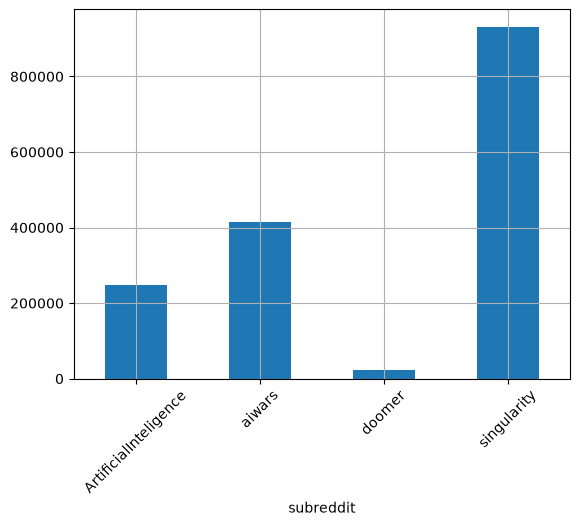

In [22]:
df_clean_columns.groupby('subreddit')['subreddit'].count().plot(kind='bar', grid=True, rot=45)

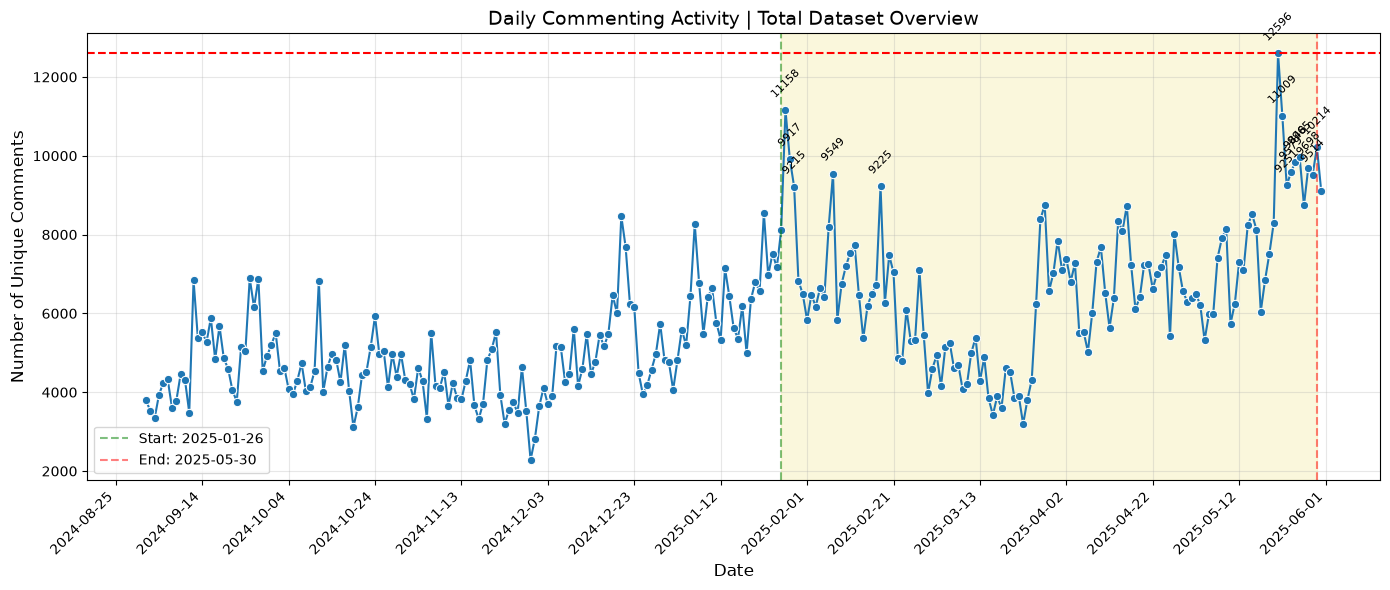

In [23]:
from datetime import timedelta

# 1. Повертаємо колонку часу в df_clean_columns з оригінального df
# Перевіряємо, які колонки вам потрібні (обов'язково додаємо 'created_utc')
columns_to_keep = ['id', 'author', 'body', 'subreddit', 'created_utc'] 
# Якщо оригінальний df все ще в пам'яті, оновлюємо наш робочий датасет:
df_clean_columns = df[columns_to_keep].copy()

# 2. Видаляємо дублікати (якщо один автор написав однаковий текст)
filtered_df = df_clean_columns.drop_duplicates(subset=['author', 'body'], keep='first')

# 3. Перетворюємо колонку created_utc на дату.
# Перевіряємо, чи це Unix timestamp (секунди) чи просто текст
if pd.api.types.is_numeric_dtype(filtered_df['created_utc']):
    filtered_df['date'] = pd.to_datetime(filtered_df['created_utc'], unit='s').dt.date
else:
    filtered_df['date'] = pd.to_datetime(filtered_df['created_utc'], errors='coerce').dt.date

# 4. Рахуємо кількість коментарів за кожен день
daily_counts = filtered_df['date'].value_counts().sort_index()
daily_counts_df = daily_counts.reset_index()
daily_counts_df.columns = ['Date', 'Comment_Count']

# 5. Будуємо графік
plt.figure(figsize=(14, 6))
sns.lineplot(x='Date', y='Comment_Count', data=daily_counts_df, marker='o')

# 6. Розраховуємо 95-й перцентиль (поріг аномальної активності)
threshold = daily_counts_df['Comment_Count'].quantile(0.95)
above_threshold = daily_counts_df[daily_counts_df['Comment_Count'] > threshold]

# 7. Виділяємо піковий період кольором та лініями
if not above_threshold.empty:
    first_date = above_threshold['Date'].min() - timedelta(days=1)
    last_date = above_threshold['Date'].max()

    plt.axvline(first_date, color='green', linestyle='--', alpha=0.5, label=f'Start: {first_date}')
    plt.axvline(last_date, color='red', linestyle='--', alpha=0.5, label=f'End: {last_date}')
    plt.axvspan(first_date, last_date, color='khaki', alpha=0.3)

# 8. Додаємо цифри (підписи) над піковими точками
for idx, row in daily_counts_df.iterrows():
    if row['Comment_Count'] > threshold:
        plt.text(row['Date'], row['Comment_Count'] + (daily_counts_df['Comment_Count'].max() * 0.02), 
                 str(int(row['Comment_Count'])),
                 ha='center', va='bottom', fontsize=8, rotation=45)

# 9. Налаштування осей, легенди та заголовку
plt.xticks(rotation=45, ha='right')
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(15))  
plt.axhline(y=daily_counts_df['Comment_Count'].max(), color='r', linestyle='--')

plt.title('Daily Commenting Activity | Total Dataset Overview', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Unique Comments', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()